In [1]:
#imports and libraries
!py -m pip install seaborn
import numpy as np
import pandas as pd
import joblib as jl
import sys
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import cross_val_score,TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    root_mean_squared_error
)
from matplotlib import pyplot as plt
import seaborn as sb

sys.path.append("..")



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
train=pd.read_csv("../data/processed/train.csv")
val=pd.read_csv("../data/processed/val.csv")
test=pd.read_csv("../data/processed/test.csv")

xtrainScaled_smote=np.load("../data/processed/xtrain_scaled.npy")
ytrainSeverity_smote=np.load("../data/processed/ytrain_severity.npy")

FEATURES = [

    "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "water_proxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
TARGET = "cases"

xtrainScaled=train[FEATURES]
xvalScaled=val[FEATURES]
xtestScaled=test[FEATURES]
ytrain=train[TARGET]
yval=val[TARGET]
ytest=test[TARGET]

In [3]:
# helper function to evaluate the model accuracy for the regressors

def regressorEvaluation(model,xtest,ytest):

    predictions=model.predict(xtest)
    meanSquareError=mean_squared_error(ytest, predictions)
    r2=r2_score(ytest, predictions)
    rootMeanSquareError=root_mean_squared_error(ytest, predictions)
    meanAbsoluteError=mean_absolute_error(ytest, predictions)
    print("The Model Performance metrics are:")
    print(f"R2 Score: {r2}")
    print(f"Mean Squared Error: {meanSquareError}")
    print(f"Root Mean Squared Error: {rootMeanSquareError}")
    print(f"Mean Absolute Error: {meanAbsoluteError}")

    return {
        "R2_Score": r2,
        "MeanSquaredError": meanSquareError,
        "RootMeanSquaredError": rootMeanSquareError,
        "MeanAbsoluteError": meanAbsoluteError
    }

In [6]:
#Linear Regression as baseline model

linearRegression=LinearRegression()

linearRegression.fit(xtrainScaled,ytrain)

linearEvaluations=regressorEvaluation(linearRegression,xvalScaled,yval)

timecv=TimeSeriesSplit(n_splits=5)
cvScore=cross_val_score(linearRegression,xtrainScaled,ytrain,cv=timecv,scoring='r2')

print(f"Cross Validation Average R2 Score: {cvScore.mean():.4f}")
print(f"Cross Validation R2 Scores Std: {cvScore.std():.4f}")
print(f"Mean: {cvScore.mean():.4f} ± {cvScore.std():.4f}")
#jl.dump( linearRegression,"../models/linear_baseline.pkl")

The Model Performance metrics are:
R2 Score: 0.605085456631112
Mean Squared Error: 424.253770658575
Root Mean Squared Error: 20.597421456545842
Mean Absolute Error: 8.155416331360763
Cross Validation Average R2 Score: 0.7060
Cross Validation R2 Scores Std: 0.0744
Mean: 0.7060 ± 0.0744


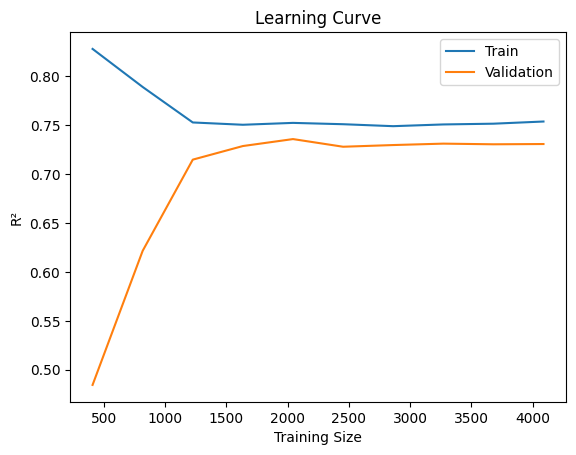

In [7]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    linearRegression, xtrainScaled, ytrain, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1),   label='Validation')
plt.xlabel('Training Size')
plt.ylabel('R²')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [ ]:
#randomforest regressor

FEATURES_RF = [

    "district_encoded","T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "water_proxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
TARGET_RF = "cases"

xtrainScaled_rf=train[FEATURES_RF]
xvalScaled_rf=val[FEATURES_RF]
xtestScaled_rf=test[FEATURES_RF]
ytrain_rf=train[TARGET_RF]
yval_rf=val[TARGET_RF]
ytest_rf=test[TARGET_RF]

model = RandomForestRegressor(n_estimators=200)
model.fit(xtrainScaled_rf, ytrain_rf)
evaluation=regressorEvaluation(model, xvalScaled_rf, yval_rf)
importance = model.feature_importances_

scores = cross_val_score(model, xtrainScaled_rf, ytrain_rf, cv=5, scoring='r2')

print(f"CV R² scores: {scores}")
print(f"Mean: {scores.mean():.4f} ± {scores.std():.4f}")


The Model Performance metrics are:
R2 Score: 0.22847688629540996
Mean Squared Error: 828.8415699942129
Root Mean Squared Error: 28.78960871554549
Mean Absolute Error: 10.286944444444442


In [33]:
print("Train cases distribution:")
print(train['cases'].describe())
print(f"\nTrain max: {train['cases'].max()}")
print(f"Val max: {val['cases'].max()}")
print(f"Test max: {test['cases'].max()}")

# Check year distribution
print("\nTrain year range:", train['year'].min(), "-", train['year'].max())
print("Val year range:", val['year'].min(), "-", val['year'].max())
print("Test year range:", test['year'].min(), "-", test['year'].max())

Train cases distribution:
count    5997.000000
mean        3.656828
std         3.811296
min         0.000000
25%         2.000000
50%         2.000000
75%         4.000000
max        43.000000
Name: cases, dtype: float64

Train max: 43
Val max: 362
Test max: 36

Train year range: 2016 - 2019
Val year range: 2019 - 2020
Test year range: 2020 - 2020
